In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from wassa_functions import allen_reconstruction_comparison
from wassa_plots import make_violin
import matplotlib.pyplot as plt

## Get statistics from real data

In [3]:
dataset_name = 'allen_data_by_image'
device = 'cpu'
dataset_path = '../../'+dataset_name+'/*'

In [4]:
training_parameters_emd = {
    'kernel_size' : (1, 1, 1),
    'loss_type' : 'emd',
    'activation' : 'emd like',
    'sigmoid' : False,
    'kernels_norm' : 2,
    'N_learnsteps' : 2000,
    'learning_rate' : .01,
    'penalty_type' : [None],
    'lambda' : [0],
    'batch_size' : None,
    'do_bias' : False,
    'weight_init' : 'flat',
    'normalize_input' : True,
}

In [5]:
saving_path = '../../wassa_copy/2025-09-30_static/results/wassa_allen_'
metric_names = ['training loss', 'testing loss', 'activations', 'explained variance']

In [6]:
results_emd = allen_reconstruction_comparison(dataset_name,training_parameters_emd,metric_names,saving_path=saving_path,device=device)

  0%|          | 0/3200 [00:00<?, ?it/s]

In [7]:
training_parameters_mse = {
    'kernel_size' : (1, 1, 1),
    'loss_type' : 'mse',
    'activation' : 'conv',
    'sigmoid' : False,
    'kernels_norm' : 2,
    'N_learnsteps' : 600,
    'learning_rate' : .05,
    'penalty_type' : [None],
    'lambda' : [0],
    'batch_size' : None,
    'do_bias' : False,
    'weight_init' : 'flat',
    'normalize_input' : True
}

In [8]:
results_mse = allen_reconstruction_comparison(dataset_name,training_parameters_mse,metric_names,saving_path=saving_path,device=device)

  0%|          | 0/3200 [00:00<?, ?it/s]

In [9]:
training_parameters_frs = {
    'kernel_size' : (1, 1, 1),
    'loss_type' : 'mse',
    'activation' : 'conv',
    'sigmoid' : False,
    'kernels_norm' : 2,
    'N_learnsteps' : 2000,
    'learning_rate' : .05,
    'penalty_type' : [None],
    'lambda' : [0],
    'batch_size' : None,
    'do_bias' : False,
    'weight_init' : 'flat',
    'normalize_input' : False
}

In [10]:
results_frs = allen_reconstruction_comparison(dataset_name,training_parameters_mse,metric_names,frs=True,saving_path=saving_path,device=device)

  0%|          | 0/3200 [00:00<?, ?it/s]

/home/antoine/miniconda3/envs/wassa/lib/python3.12/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


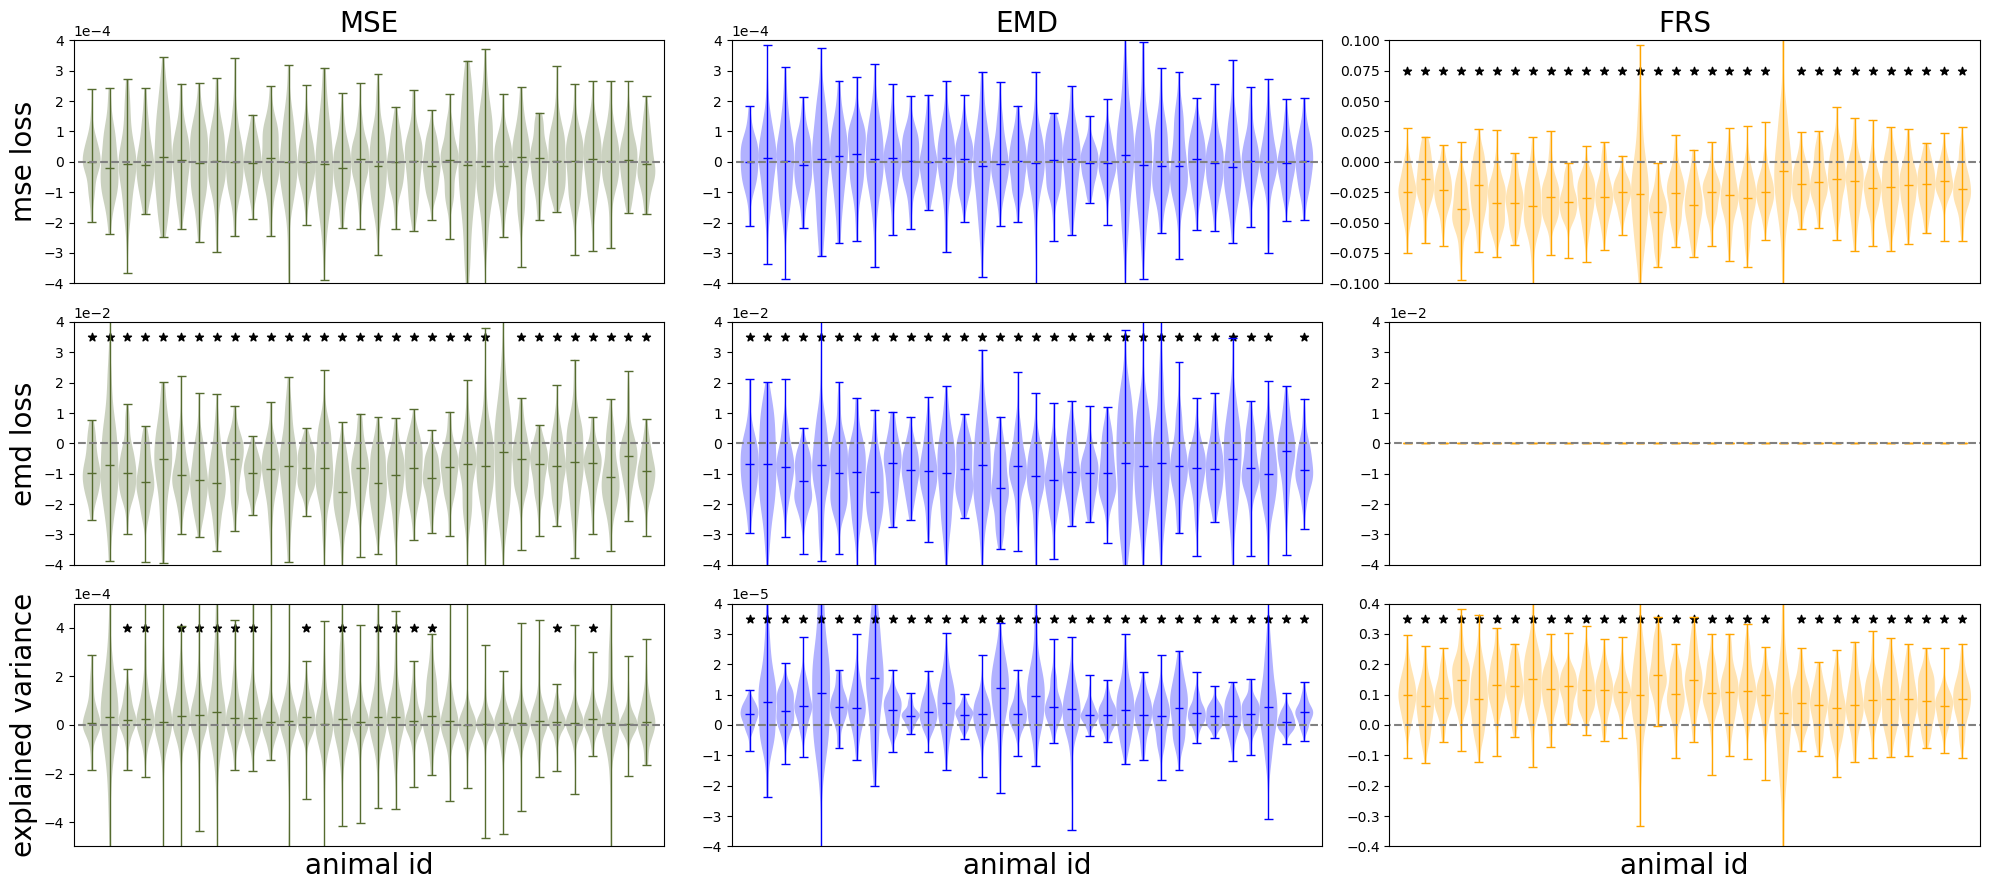

In [61]:
all_metrics = ['mse loss', 'emd loss', 'explained variance']
fig, ax = plt.subplots(len(all_metrics),3,figsize=(20,9))

separation_coef = .5
offset = 1
significance_threshold = 1e-3

for i in range(len(all_metrics)):
    if i == 0:
        amp = .075
    else:
        amp = 3.5e-2

    reshaped = results_mse[:,i].reshape(32,100,3).swapaxes(0,2)
    results_mse_per_animal = reshaped[1]-reshaped[2]
    ax[i,0] = make_violin(ax[i,0],results_mse_per_animal,['darkolivegreen'], separation_coef=separation_coef, offset=offset)
    for a in range(32):
        if i == 2:
            amp = 4e-4
            t_stat, p_value = scipy.stats.wilcoxon(results_mse_per_animal[:,a],alternative='greater')
        else:
            t_stat, p_value = scipy.stats.wilcoxon(results_mse_per_animal[:,a],alternative='less')
        if p_value < significance_threshold:
            ax[i,0].scatter(offset+a*separation_coef,amp,marker='*',color='black')
    ax[i,0].set_xticks([])
    ax[i,0].set_ylabel(all_metrics[i],fontsize=20)
    ax[i,0].ticklabel_format(axis='both', style='sci', scilimits=(-2,1))
    ax[i,0].hlines(0,0,results_mse_per_animal.shape[1]*separation_coef+1,linestyles='dashed',colors='grey')
    ax[i,0].set_xlim([separation_coef,results_mse_per_animal.shape[1]*separation_coef+1])

    reshaped = results_emd[:,i].reshape(32,100,3).swapaxes(0,2)
    results_emd_per_animal = reshaped[1]-reshaped[2]
    ax[i,1] = make_violin(ax[i,1],results_emd_per_animal,'blue')
    for a in range(32):
        if i == 2:
            amp = 3.5e-5
            t_stat, p_value = scipy.stats.wilcoxon(results_emd_per_animal[:,a],alternative='greater')
        else:
            t_stat, p_value = scipy.stats.wilcoxon(results_emd_per_animal[:,a],alternative='less')
        if p_value < significance_threshold:
            ax[i,1].scatter(offset+a*separation_coef,amp,marker='*',color='black')
    ax[i,1].set_xticks([])
    #ax[i,1].set_ylim([min(np.quantile(results_emd[:,i],.1,axis=0)), max(np.quantile(results_emd[:,i],.9,axis=0))])
    ax[i,1].ticklabel_format(axis='both', style='sci', scilimits=(-2,1))
    ax[i,1].hlines(0,0,results_mse_per_animal.shape[1]*separation_coef+1,linestyles='dashed',colors='grey')
    ax[i,1].set_xlim([separation_coef,results_mse_per_animal.shape[1]*separation_coef+1])

    reshaped = results_frs[:,i].reshape(32,100,3).swapaxes(0,2)
    results_frs_per_animal = reshaped[1]-reshaped[2]
    ax[i,2] = make_violin(ax[i,2],results_frs_per_animal,'orange')
    for a in range(32):
        if i == 2:
            amp = 3.5e-1
            t_stat, p_value = scipy.stats.wilcoxon(results_frs_per_animal[:,a],alternative='greater')
        else:
            t_stat, p_value = scipy.stats.wilcoxon(results_frs_per_animal[:,a],alternative='less')
        if p_value < significance_threshold:
            ax[i,2].scatter(offset+a*separation_coef,amp,marker='*',color='black')
    ax[i,2].set_xticks([])
    ax[i,2].ticklabel_format(axis='both', style='sci', scilimits=(-2,1))
    ax[i,2].hlines(0,0,results_mse_per_animal.shape[1]*separation_coef+1,linestyles='dashed',colors='grey')
    ax[i,2].set_xlim([separation_coef,results_mse_per_animal.shape[1]*separation_coef+1])

ax[0,0].set_title('MSE',fontsize=20)
ax[0,0].set_ylim([-4e-4,4e-4])
ax[0,1].set_title('EMD',fontsize=20)
ax[0,1].set_ylim([-4e-4,4e-4])
ax[0,2].set_title('FRS',fontsize=20)
ax[0,2].set_ylim([-.1,.1])
ax[1,1].set_ylim([-4e-2,4e-2])
ax[1,0].set_ylim([-4e-2,4e-2])
ax[1,2].set_ylim([-4e-2,4e-2])
ax[2,1].set_ylim([-4e-5,4e-5])
ax[2,0].set_ylim([-5e-4,5e-4])
ax[2,2].set_ylim([-.4,.4])
for c in range(3):
    ax[2,c].set_xlabel('animal id',fontsize=20)

fig.tight_layout()

In [62]:
fig.savefig('../figures/results_allen_per_animal.pdf', bbox_inches = 'tight')

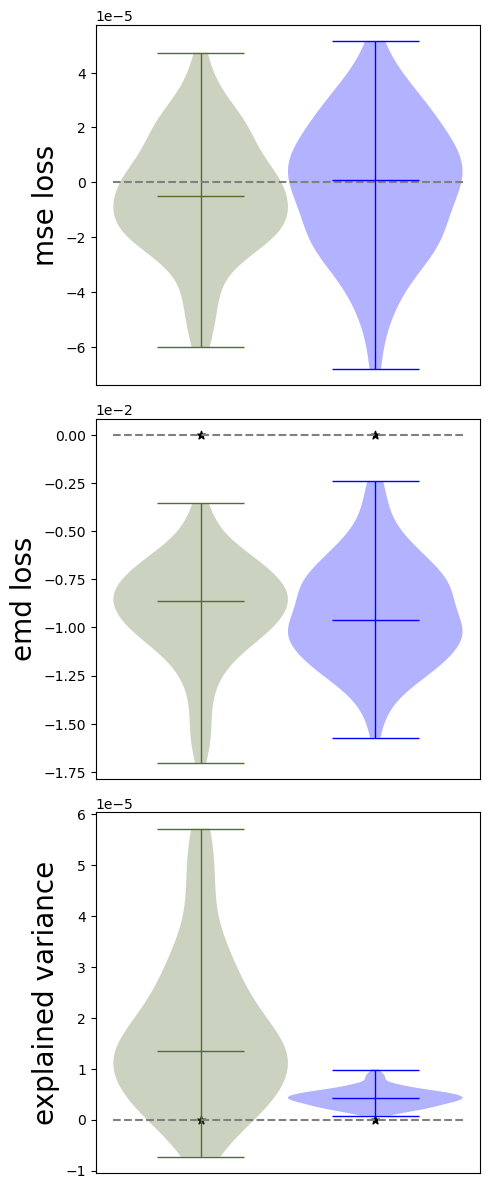

In [59]:
all_metrics = ['mse loss', 'emd loss', 'explained variance']
fig, ax = plt.subplots(len(all_metrics),1,figsize=(5,12))

separation_coef = .5
offset = 1
significance_threshold = 1e-4

for i in range(len(all_metrics)):

    reshaped = results_mse[:,i].reshape(32,100,3).swapaxes(0,2)
    results_mse_per_animal = reshaped[1]-reshaped[2]
    reshaped = results_emd[:,i].reshape(32,100,3).swapaxes(0,2)
    results_emd_per_animal = reshaped[1]-reshaped[2]
    reshaped = results_frs[:,i].reshape(32,100,3).swapaxes(0,2)
    results_frs_per_animal = reshaped[1]-reshaped[2]
    if i == 2:
        t_stat, p_value_mse = scipy.stats.wilcoxon(results_mse_per_animal.median(dim=1).values,alternative='greater')
        t_stat, p_value_emd = scipy.stats.wilcoxon(results_emd_per_animal.median(dim=1).values,alternative='greater')
    else:
        t_stat, p_value_mse = scipy.stats.wilcoxon(results_mse_per_animal.median(dim=1).values,alternative='less')
        t_stat, p_value_emd = scipy.stats.wilcoxon(results_emd_per_animal.median(dim=1).values,alternative='less')
    if p_value_mse < significance_threshold:
        ax[i].scatter(offset,0,marker='*',color='black')
    if p_value_emd < significance_threshold:
        ax[i].scatter(offset+separation_coef,0,marker='*',color='black')
    
    ax[i] = make_violin(ax[i],results_mse_per_animal.median(dim=1).values,'darkolivegreen',separation_coef=separation_coef)
    ax[i].set_xticks([])
    ax[i].set_ylabel(all_metrics[i],fontsize=20)
    ax[i].ticklabel_format(axis='both', style='sci', scilimits=(-2,1))
    ax[i].hlines(0,.75,1.75,linestyles='dashed',colors='grey')
    ax[i] = make_violin(ax[i],results_emd_per_animal.median(dim=1).values,'blue',separation_coef=separation_coef,offset=1.5)
    #ax[i,2].set_xlim([separation_coef,results_mse_per_animal.shape[1]*separation_coef+1])
    #ax[i] = make_violin(ax[i],results_frs_per_animal.median(dim=1).values,'orange',separation_coef=separation_coef,offset=2)
    ax[i].set_xlim([.7,1.8])
fig.tight_layout()

In [14]:
fig.savefig('../figures/results_allen_per_animal_averaged.pdf', bbox_inches = 'tight')

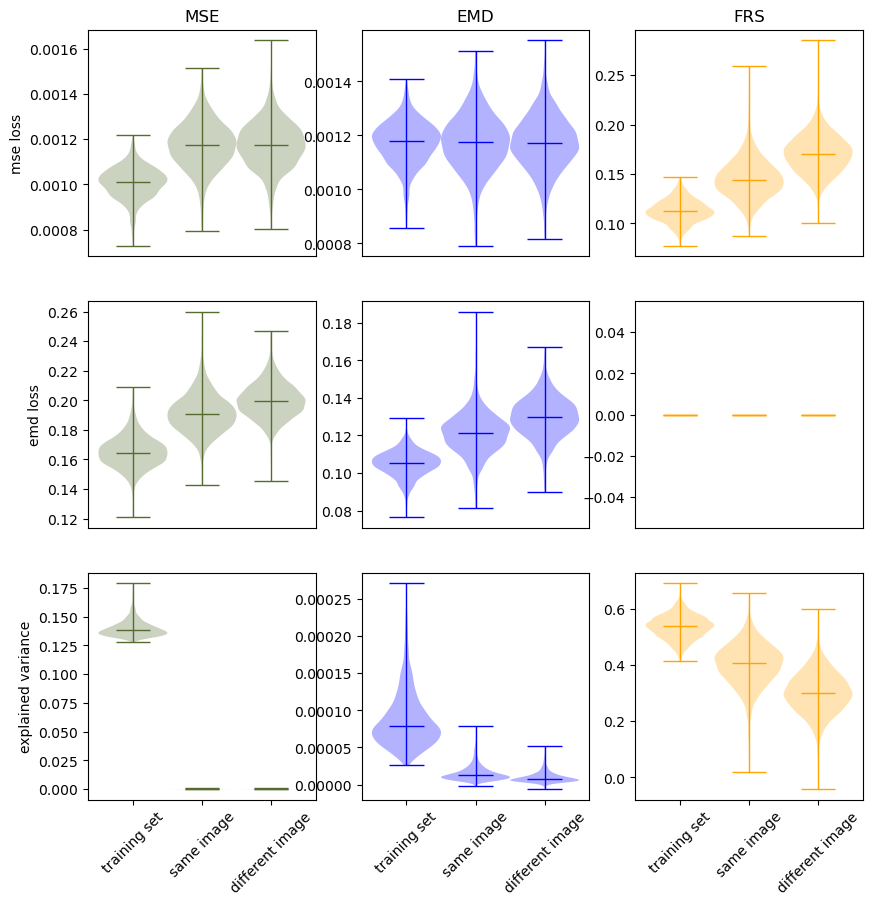

In [15]:
all_metrics = ['mse loss', 'emd loss', 'explained variance']
fig, ax = plt.subplots(len(all_metrics),3,figsize=(10,10))
for i in range(len(all_metrics)):

    ax[i,0] = make_violin(ax[i,0],results_mse[:,i],'darkolivegreen')
    #ax[i,0].set_ylim([min(mean_mse)-2*max(std_mse), max(mean_mse)+2*max(std_mse)])
    ax[i,0].set_xticks([])
    ax[i,0].set_ylabel(all_metrics[i])

    ax[i,1] = make_violin(ax[i,1],results_emd[:,i],'blue')
    ax[i,1].set_xticks([])
    
    ax[i,2] = make_violin(ax[i,2],results_frs[:,i],'orange')
    ax[i,2].set_xticks([])

ax[0,0].set_title('MSE')
ax[0,1].set_title('EMD')
ax[0,2].set_title('FRS')
ax[i,0].set_xticks([1,1.5,2], ['training set', 'same image', 'different image'], rotation=45)
ax[i,1].set_xticks([1,1.5,2], ['training set', 'same image', 'different image'], rotation=45)
ax[i,2].set_xticks([1,1.5,2], ['training set', 'same image', 'different image'], rotation=45);

In [16]:
fig.savefig('../figures/results_allen_with_trainset.pdf', bbox_inches = 'tight')

Text(0.5, 1.0, 'FRS')

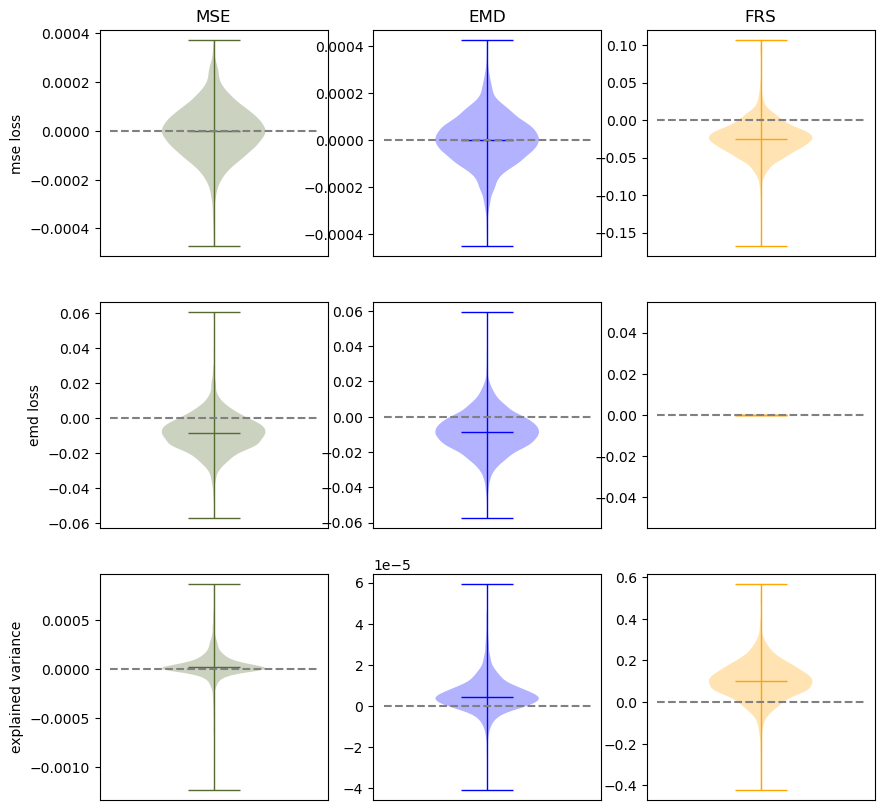

In [17]:
all_metrics = ['mse loss', 'emd loss', 'explained variance']
fig, ax = plt.subplots(len(all_metrics),3,figsize=(10,10))
for i in range(len(all_metrics)):

    ax[i,0] = make_violin(ax[i,0],results_mse[:,i,1]-results_mse[:,i,2],'darkolivegreen')
    #ax[i,0].set_ylim([min(mean_mse)-2*max(std_mse), max(mean_mse)+2*max(std_mse)])
    ax[i,0].hlines(0,.5,1.5,linestyles='dashed',colors='grey')
    ax[i,0].set_xticks([])
    ax[i,0].set_ylabel(all_metrics[i])

    ax[i,1] = make_violin(ax[i,1],results_emd[:,i,1]-results_emd[:,i,2],'blue')
    ax[i,1].hlines(0,.5,1.5,linestyles='dashed',colors='grey')
    ax[i,1].set_xticks([])
    
    ax[i,2] = make_violin(ax[i,2],results_frs[:,i,1]-results_frs[:,i,2],'orange')
    ax[i,2].hlines(0,.5,1.5,linestyles='dashed',colors='grey')
    ax[i,2].set_xticks([])

ax[0,0].set_title('MSE')
ax[0,1].set_title('EMD')
ax[0,2].set_title('FRS')

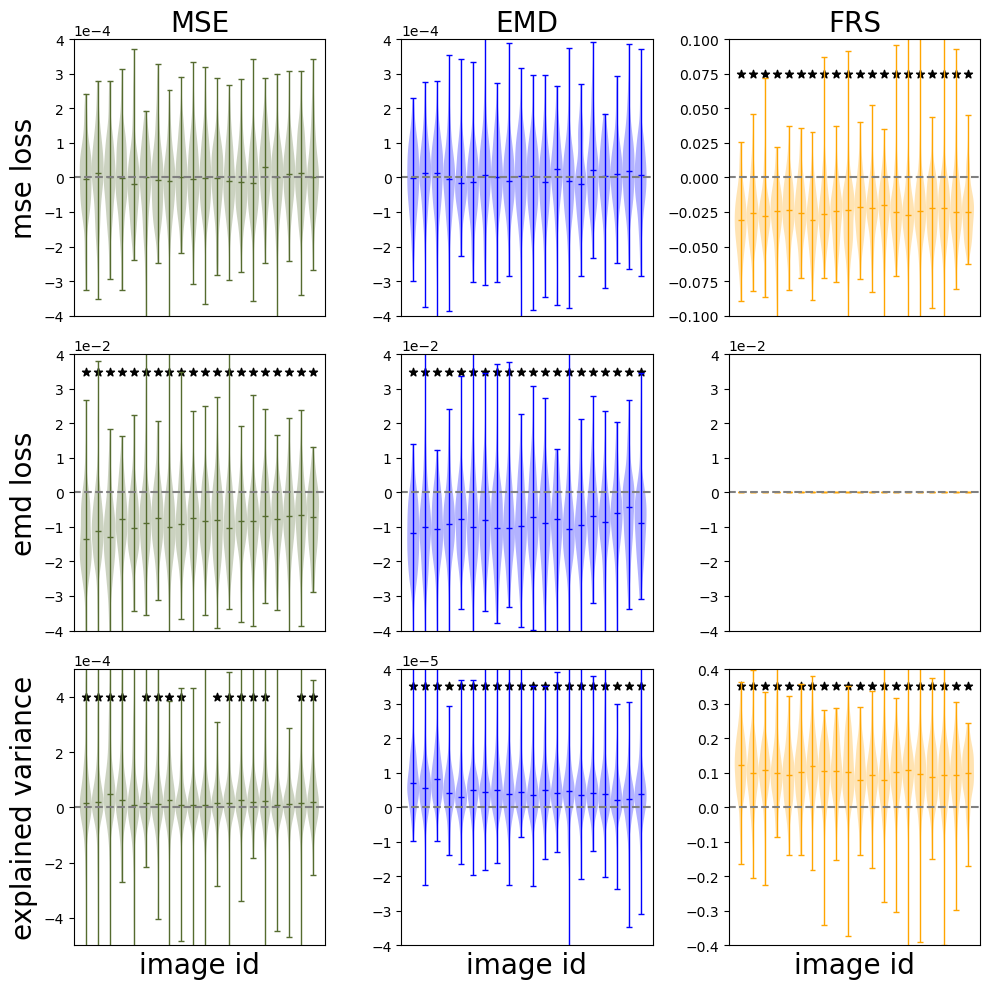

In [68]:
all_metrics = ['mse loss', 'emd loss', 'explained variance']
fig, ax = plt.subplots(len(all_metrics),3,figsize=(10,10))

for i in range(len(all_metrics)):
    if i == 0:
        amp = .075
    else:
        amp = 3.5e-2

    reshaped = results_mse[:,i].reshape(32,20,5,3).swapaxes(0,3).flatten(start_dim=2).swapaxes(1,2)
    results_mse_per_image = reshaped[1]-reshaped[2]
    ax[i,0] = make_violin(ax[i,0],results_mse_per_image,'darkolivegreen')
    for a in range(20):
        if i == 2:
            amp = 4e-4
            t_stat, p_value = scipy.stats.wilcoxon(results_mse_per_image[:,a],alternative='greater')
        else:
            t_stat, p_value = scipy.stats.wilcoxon(results_mse_per_image[:,a],alternative='less')
        if p_value < significance_threshold:
            ax[i,0].scatter(offset+a*separation_coef,amp,marker='*',color='black')
    ax[i,0].set_xticks([])
    ax[i,0].set_ylabel(all_metrics[i],fontsize=20)
    ax[i,0].ticklabel_format(axis='both', style='sci', scilimits=(-2,1))
    ax[i,0].hlines(0,0,results_mse_per_image.shape[1]*separation_coef+1,linestyles='dashed',colors='grey')
    ax[i,0].set_xlim([separation_coef,results_mse_per_image.shape[1]*separation_coef+1])

    reshaped = results_emd[:,i].reshape(32,20,5,3).swapaxes(0,3).flatten(start_dim=2).swapaxes(1,2)
    results_emd_per_image = reshaped[1]-reshaped[2]
    ax[i,1] = make_violin(ax[i,1],results_emd_per_image,'blue')
    for a in range(20):
        if i == 2:
            amp = 3.5e-5
            t_stat, p_value = scipy.stats.wilcoxon(results_emd_per_image[:,a],alternative='greater')
        else:
            t_stat, p_value = scipy.stats.wilcoxon(results_emd_per_image[:,a],alternative='less')
        if p_value < significance_threshold:
            ax[i,1].scatter(offset+a*separation_coef,amp,marker='*',color='black')
    ax[i,1].set_xticks([])
    #ax[i,1].set_ylim([min(np.quantile(results_emd[:,i],.1,axis=0)), max(np.quantile(results_emd[:,i],.9,axis=0))])
    ax[i,1].ticklabel_format(axis='both', style='sci', scilimits=(-2,1))
    ax[i,1].hlines(0,0,results_emd_per_image.shape[1]*separation_coef+1,linestyles='dashed',colors='grey')
    ax[i,1].set_xlim([separation_coef,results_emd_per_image.shape[1]*separation_coef+1])

    reshaped = results_frs[:,i].reshape(32,20,5,3).swapaxes(0,3).flatten(start_dim=2).swapaxes(1,2)
    results_frs_per_image = reshaped[1]-reshaped[2]
    ax[i,2] = make_violin(ax[i,2],results_frs_per_image,'orange')
    for a in range(20):
        if i == 2:
            amp = 3.5e-1
            t_stat, p_value = scipy.stats.wilcoxon(results_frs_per_image[:,a],alternative='greater')
        else:
            t_stat, p_value = scipy.stats.wilcoxon(results_frs_per_image[:,a],alternative='less')
        if p_value < significance_threshold:
            ax[i,2].scatter(offset+a*separation_coef,amp,marker='*',color='black')    
    ax[i,2].set_xticks([])
    ax[i,2].ticklabel_format(axis='both', style='sci', scilimits=(-2,1))
    ax[i,2].hlines(0,0,results_frs_per_image.shape[1]*separation_coef+1,linestyles='dashed',colors='grey')
    ax[i,2].set_xlim([separation_coef,results_frs_per_image.shape[1]*separation_coef+1])

ax[0,0].set_title('MSE',fontsize=20)
ax[0,0].set_ylim([-4e-4,4e-4])
ax[0,1].set_title('EMD',fontsize=20)
ax[0,1].set_ylim([-4e-4,4e-4])
ax[0,2].set_title('FRS',fontsize=20)
ax[0,2].set_ylim([-.1,.1])
ax[1,1].set_ylim([-4e-2,4e-2])
ax[1,0].set_ylim([-4e-2,4e-2])
ax[1,2].set_ylim([-4e-2,4e-2])
ax[2,1].set_ylim([-4e-5,4e-5])
ax[2,0].set_ylim([-5e-4,5e-4])
ax[2,2].set_ylim([-.4,.4])
for c in range(3):
    ax[2,c].set_xlabel('image id',fontsize=20)
#ax[i,0].set_xticks([1,1.5], ['same\nimage', 'different\nimage'], rotation=45,fontsize=12)
#ax[i,1].set_xticks([1,1.5], ['same\nimage', 'different\nimage'], rotation=45,fontsize=12)
#ax[i,2].set_xticks([1,1.5], ['same\nimage', 'different\nimage'], rotation=45,fontsize=12)

fig.tight_layout()

In [19]:
import scipy
import numpy as np

equal_var=False
all_metrics = ['mse loss', 'emd loss', 'explained variance']
all_losses = ['MSE training', 'EMD training', 'FRS training']
results_t_test = np.zeros([3,3,2])
all_results = [results_mse, results_emd, results_frs]
for ind_metric in range(3):
    for ind_training_loss in range(3):
        t_stat, p_value = scipy.stats.ttest_ind(all_results[ind_training_loss][:,ind_metric,1],all_results[ind_training_loss][:,ind_metric,2], equal_var=equal_var, alternative='two-sided')
        results_t_test[ind_training_loss,ind_metric] = t_stat, p_value
        print(f'For {all_losses[ind_training_loss]} and {all_metrics[ind_metric]} : {t_stat} - p-value : {p_value}')

For MSE training and mse loss : -0.617275705392383 - p-value : 0.5370748645992347
For EMD training and mse loss : 0.22962893394770234 - p-value : 0.8183874785384834
For FRS training and mse loss : -51.65326428939198 - p-value : 0.0
For MSE training and emd loss : -27.234722256745563 - p-value : 1.4557076489141679e-154
For EMD training and emd loss : -32.7442027861507 - p-value : 1.4761787165117475e-217
For FRS training and emd loss : nan - p-value : nan
For MSE training and explained variance : 14.356078265369721 - p-value : 5.3541403349746435e-46
For EMD training and explained variance : 24.75763828125974 - p-value : 1.1973290156794071e-128
For FRS training and explained variance : 54.31345916403382 - p-value : 0.0


In [20]:
import scipy
equal_var=False
all_metrics = ['mse loss', 'emd loss', 'explained variance']
all_losses = ['MSE training', 'EMD training', 'FRS training']
results_t_test = np.zeros([3,3,2])
all_results = [results_mse, results_emd, results_frs]
for ind_metric in range(3):
    for ind_training_loss in range(3):
        t_stat, p_value = scipy.stats.ttest_1samp(all_results[ind_training_loss][:,ind_metric,1]-all_results[ind_training_loss][:,ind_metric,2], 0)
        results_t_test[ind_training_loss,ind_metric] = t_stat, p_value
        print(f'For {all_losses[ind_training_loss]} and {all_metrics[ind_metric]} : {t_stat} - p-value : {p_value}')

For MSE training and mse loss : -0.8415038112414683 - p-value : 0.40012864992899155
For EMD training and mse loss : 0.3098204430468546 - p-value : 0.7567176846735466
For FRS training and mse loss : -62.25446038349348 - p-value : 0.0
For MSE training and emd loss : -46.574195098881695 - p-value : 0.0
For EMD training and emd loss : -42.784759079743246 - p-value : 1.1093237e-316
For FRS training and emd loss : nan - p-value : nan
For MSE training and explained variance : 14.930001309331297 - p-value : 8.897199584012906e-49
For EMD training and explained variance : 35.88268165780375 - p-value : 2.842764609450874e-237
For FRS training and explained variance : 62.2628287964935 - p-value : 0.0


In [84]:
import scipy
equal_var=False
all_metrics = ['mse loss', 'emd loss', 'explained variance']
all_losses = ['MSE training', 'EMD training', 'FRS training']
results_t_test = np.zeros([3,3,2])
all_results = [results_mse, results_emd, results_frs]
for ind_metric in range(3):
    for ind_training_loss in range(3):
        if ind_metric == 2:
            stats = pg.ttest(all_results[ind_training_loss][:,ind_metric,1]-all_results[ind_training_loss][:,ind_metric,2], 0)
        else:
            stats = pg.ttest(all_results[ind_training_loss][:,ind_metric,2]-all_results[ind_training_loss][:,ind_metric,1], 0)
        #results_t_test[ind_training_loss,ind_metric] = t_stat, p_value
        print(f'For {all_losses[ind_training_loss]} and {all_metrics[ind_metric]} : cohen D {stats['cohen-d'][0]} - p-value : {stats['p-val'][0]} - bayes factor {stats['BF10'][0]}')

For MSE training and mse loss : cohen D 0.014875826103372847 - p-value : 0.40012864992899155 - bayes factor 0.028
For EMD training and mse loss : cohen D 0.005476903382687388 - p-value : 0.7567176846735466 - bayes factor 0.021
For FRS training and mse loss : cohen D 1.1005137806417904 - p-value : 0.0 - bayes factor inf
For MSE training and emd loss : cohen D 0.8233232131171732 - p-value : 0.0 - bayes factor inf
For EMD training and emd loss : cohen D 0.7563348191324802 - p-value : 1.1093237e-316 - bayes factor inf
For FRS training and emd loss : cohen D nan - p-value : nan - bayes factor nan
For MSE training and explained variance : cohen D 0.26392761737891024 - p-value : 8.897199584012906e-49 - bayes factor 1.12e+45
For EMD training and explained variance : cohen D 0.634322212801745 - p-value : 2.842764609450874e-237 - bayes factor 1.212e+233
For FRS training and explained variance : cohen D 1.100661680757536 - p-value : 0.0 - bayes factor inf


/tmp/ipykernel_4170538/1686208072.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f'For {all_losses[ind_training_loss]} and {all_metrics[ind_metric]} : cohen D {stats['cohen-d'][0]} - p-value : {stats['p-val'][0]} - bayes factor {stats['BF10'][0]}')
/tmp/ipykernel_4170538/1686208072.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f'For {all_losses[ind_training_loss]} and {all_metrics[ind_metric]} : cohen D {stats['cohen-d'][0]} - p-value : {stats['p-val'][0]} - bayes factor {stats['BF10'][0]}')
/tmp/ipykernel_4170538/1686208072.py:14: FutureWarning: Series.__getitem__ treating keys as positions 

In [21]:
import scipy
equal_var=False
all_metrics = ['mse loss', 'emd loss', 'explained variance']
all_losses = ['MSE training', 'EMD training', 'FRS training']
all_results = [results_mse, results_emd, results_frs]
for ind_metric in range(3):
    for ind_training_loss in range(3):
        t_stat, p_value = scipy.stats.mood(all_results[ind_training_loss][:,ind_metric,1],all_results[ind_training_loss][:,ind_metric,2],alternative='two-sided')
        print(f'For {all_losses[ind_training_loss]} and {all_metrics[ind_metric]} : {t_stat} - p-value : {p_value}')

For MSE training and mse loss : 0.3896659964807032 - p-value : 0.6967835437055127
For EMD training and mse loss : 1.8297897558547132 - p-value : 0.0672813832255689
For FRS training and mse loss : 3.4644608803763752 - p-value : 0.000531295407382832
For MSE training and emd loss : 6.518319180284443 - p-value : 7.109957680973503e-11
For EMD training and emd loss : -1.545764458399028 - p-value : 0.12216146354950977
For FRS training and emd loss : 0.0 - p-value : 1.0
For MSE training and explained variance : 1.5997981133612393 - p-value : 0.1096433775020508
For EMD training and explained variance : -3.6617707042412238 - p-value : 0.00025047800052407763
For FRS training and explained variance : 3.231916775011236 - p-value : 0.0012296286329807184


In [22]:
import scipy
equal_var=False
all_metrics = ['mse loss', 'emd loss', 'explained variance']
all_losses = ['MSE training', 'EMD training', 'FRS training']
all_results = [results_mse, results_emd, results_frs]
for ind_metric in range(3):
    for ind_training_loss in range(3):
        t_stat, p_value = scipy.stats.mannwhitneyu(all_results[ind_training_loss][:,ind_metric,1],all_results[ind_training_loss][:,ind_metric,2],alternative='two-sided')
        print(f'For {all_losses[ind_training_loss]} and {all_metrics[ind_metric]} : {t_stat} - p-value : {p_value}')

For MSE training and mse loss : 5077790.0 - p-value : 0.5679186856129681
For EMD training and mse loss : 5157411.0 - p-value : 0.612725988528814
For FRS training and mse loss : 1782901.5 - p-value : 0.0
For MSE training and emd loss : 3120495.0 - p-value : 3.383380215670606e-161
For EMD training and emd loss : 2801869.5 - p-value : 5.949741873162229e-216
For FRS training and emd loss : 5120000.0 - p-value : 1.0
For MSE training and explained variance : 6350961.0 - p-value : 2.7543442466621744e-62
For EMD training and explained variance : 7112075.5 - p-value : 5.108277015006761e-160
For FRS training and explained variance : 8571577.5 - p-value : 0.0


In [23]:
import scipy
equal_var=False
all_metrics = ['mse loss', 'emd loss', 'explained variance']
all_losses = ['MSE training', 'EMD training', 'FRS training']
all_results = [results_mse, results_emd, results_frs]
for ind_metric in range(3):
    for ind_training_loss in range(3):
        if ind_metric==2:
            err_A, err_B = all_results[ind_training_loss][:,ind_metric,1],all_results[ind_training_loss][:,ind_metric,2]
        else:
            err_B, err_A = all_results[ind_training_loss][:,ind_metric,1],all_results[ind_training_loss][:,ind_metric,2]
        t_stat, p_value = scipy.stats.wilcoxon(err_A, err_B)
        print(f'For {all_losses[ind_training_loss]} and {all_metrics[ind_metric]} : {t_stat} - p-value : {p_value}')

For MSE training and mse loss : 2512090.5 - p-value : 0.35137906815243636
For EMD training and mse loss : 2528882.0 - p-value : 0.5414246195307643
For FRS training and mse loss : 275833.0 - p-value : 0.0
For MSE training and emd loss : 575708.0 - p-value : 0.0
For EMD training and emd loss : 685484.0 - p-value : 6.5329610066773774e-282
For FRS training and emd loss : 0.0 - p-value : nan
For MSE training and explained variance : 1648619.5 - p-value : 2.362197812196702e-67
For EMD training and explained variance : 751095.0 - p-value : 4.4224827692846554e-260
For FRS training and explained variance : 282422.0 - p-value : 0.0


/home/antoine/miniconda3/envs/wassa/lib/python3.12/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


In [24]:
def paired_permutation_test(a, b, n_perm=10000, alternative="greater"):
    d = b - a  # différence dans le sens que tu veux tester
    observed = np.mean(d)
    
    perm_stats = []
    for _ in range(n_perm):
        signs = np.random.choice([1, -1], size=len(d))
        perm_stats.append(np.mean(signs * d))
    perm_stats = np.array(perm_stats)

    if alternative == "greater":
        p_value = np.mean(perm_stats >= observed)
    elif alternative == "less":
        p_value = np.mean(perm_stats <= observed)
    else:  # two-sided
        p_value = np.mean(np.abs(perm_stats) >= abs(observed))

    return observed, p_value

In [25]:
def paired_permutation_test_median(a, b, n_perm=10000, alternative="greater"):
    d = b - a  # différence dans le sens que tu veux tester
    observed = np.median(d)
    
    perm_stats = []
    for _ in range(n_perm):
        signs = np.random.choice([1, -1], size=len(d))
        perm_stats.append(np.mean(signs * d))
    perm_stats = np.array(perm_stats)

    if alternative == "greater":
        p_value = np.mean(perm_stats >= observed)
    elif alternative == "less":
        p_value = np.mean(perm_stats <= observed)
    else:  # two-sided
        p_value = np.mean(np.abs(perm_stats) >= abs(observed))

    return observed, p_value

In [26]:
def compute_auc(a, b):
    # Proba que un élément de B soit > un élément de A
    count = 0
    total = 0
    for x in a:
        for y in b:
            if y > x:
                count += 1
            total += 1
    return count / total

In [27]:
import scipy
equal_var=False
all_metrics = ['mse loss', 'emd loss', 'explained variance']
all_losses = ['MSE training', 'EMD training', 'FRS training']
all_results = [results_mse, results_emd, results_frs]
for ind_metric in range(3):
    for ind_training_loss in range(3):
        t_stat = compute_auc(all_results[ind_training_loss][:,ind_metric,1].numpy(),all_results[ind_training_loss][:,ind_metric,2].numpy())
        print(f'For {all_losses[ind_training_loss]} and {all_metrics[ind_metric]} : {t_stat}')

For MSE training and mse loss : 0.504121875
For EMD training and mse loss : 0.49634638671875
For FRS training and mse loss : 0.8258884765625
For MSE training and emd loss : 0.6952640625
For EMD training and emd loss : 0.7263798828125
For FRS training and emd loss : 0.0
For MSE training and explained variance : 0.3794875
For EMD training and explained variance : 0.30423037109375
For FRS training and explained variance : 0.1629318359375


In [28]:
import scipy
equal_var=False
all_metrics = ['mse loss', 'emd loss', 'explained variance']
all_losses = ['MSE training', 'EMD training', 'FRS training']
all_results = [results_mse, results_emd, results_frs]
for ind_metric in range(3):
    for ind_training_loss in range(3):
        if ind_metric==2:
            err_A, err_B = all_results[ind_training_loss][:,ind_metric,1].numpy(),all_results[ind_training_loss][:,ind_metric,2].numpy()
        else:
            err_B, err_A = all_results[ind_training_loss][:,ind_metric,1].numpy(),all_results[ind_training_loss][:,ind_metric,2].numpy()
        t_stat, p_value = paired_permutation_test(err_B,err_A)
        print(f'For {all_losses[ind_training_loss]} and {all_metrics[ind_metric]} : {t_stat} - p-value : {p_value}')

For MSE training and mse loss : 1.594117634340364e-06 - p-value : 0.2027
For EMD training and mse loss : -5.85523366680718e-07 - p-value : 0.6199
For FRS training and mse loss : 0.025046180933713913 - p-value : 0.0
For MSE training and emd loss : 0.008667504414916039 - p-value : 0.0
For EMD training and emd loss : 0.008706212975084782 - p-value : 0.0
For FRS training and emd loss : 0.0 - p-value : 1.0
For MSE training and explained variance : 3.384405863471329e-05 - p-value : 0.0
For EMD training and explained variance : 5.4000320233171806e-06 - p-value : 0.0
For FRS training and explained variance : 0.09961805492639542 - p-value : 0.0


In [29]:
import scipy
equal_var=False
all_metrics = ['mse loss', 'emd loss', 'explained variance']
all_losses = ['MSE training', 'EMD training', 'FRS training']
all_results = [results_mse, results_emd, results_frs]
for ind_metric in range(3):
    for ind_training_loss in range(3):
        if ind_metric==2:
            err_A, err_B = all_results[ind_training_loss][:,ind_metric,1].numpy(),all_results[ind_training_loss][:,ind_metric,2].numpy()
        else:
            err_B, err_A = all_results[ind_training_loss][:,ind_metric,1].numpy(),all_results[ind_training_loss][:,ind_metric,2].numpy()
        t_stat, p_value = paired_permutation_test_median(err_B,err_A)
        print(f'For {all_losses[ind_training_loss]} and {all_metrics[ind_metric]} : {t_stat} - p-value : {p_value}')

For MSE training and mse loss : 1.3957032933831215e-06 - p-value : 0.2281
For EMD training and mse loss : -1.7629936337471008e-06 - p-value : 0.8291
For FRS training and mse loss : 0.025021664798259735 - p-value : 0.0
For MSE training and emd loss : 0.008687734603881836 - p-value : 0.0
For EMD training and emd loss : 0.008855700492858887 - p-value : 0.0
For FRS training and emd loss : 0.0 - p-value : 1.0
For MSE training and explained variance : 1.6391277313232422e-05 - p-value : 0.0
For EMD training and explained variance : 4.410743713378906e-06 - p-value : 0.0
For FRS training and explained variance : 0.10045436024665833 - p-value : 0.0


In [38]:
import scipy
equal_var=False
all_metrics = ['mse loss', 'emd loss', 'explained variance']
all_losses = ['MSE training', 'EMD training', 'FRS training']
all_results = [results_mse, results_emd, results_frs]
for ind_metric in range(3):
    for ind_training_loss in range(3):
        if ind_metric==2:
            err_A, err_B = all_results[ind_training_loss][:,ind_metric,1].reshape(32,100).median(dim=1).values,all_results[ind_training_loss][:,ind_metric,2].reshape(32,100).median(dim=1).values
        else:
            err_B, err_A = all_results[ind_training_loss][:,ind_metric,1].reshape(32,100).median(dim=1).values,all_results[ind_training_loss][:,ind_metric,2].reshape(32,100).median(dim=1).values
        t_stat, p_value = scipy.stats.wilcoxon(err_A-err_B, alternative='greater')
        print(f'For {all_losses[ind_training_loss]} and {all_metrics[ind_metric]} : {t_stat} - p-value : {p_value}')

For MSE training and mse loss : 308.0 - p-value : 0.2105629900470376
For EMD training and mse loss : 243.0 - p-value : 0.6542108685243875
For FRS training and mse loss : 528.0 - p-value : 2.3283064365386963e-10
For MSE training and emd loss : 528.0 - p-value : 2.3283064365386963e-10
For EMD training and emd loss : 528.0 - p-value : 2.3283064365386963e-10
For FRS training and emd loss : 0.0 - p-value : nan
For MSE training and explained variance : 528.0 - p-value : 2.3283064365386963e-10
For EMD training and explained variance : 528.0 - p-value : 3.9676561336219917e-07
For FRS training and explained variance : 528.0 - p-value : 2.3283064365386963e-10


In [40]:
import scipy
equal_var=False
all_metrics = ['mse loss', 'emd loss', 'explained variance']
all_losses = ['MSE training', 'EMD training', 'FRS training']
all_results = [results_mse, results_emd, results_frs]
for ind_metric in range(3):
    for ind_training_loss in range(3):
        if ind_metric==2:
            err_A, err_B = all_results[ind_training_loss][:,ind_metric,1].reshape(32,100).median(dim=1).values.numpy(),all_results[ind_training_loss][:,ind_metric,2].reshape(32,100).median(dim=1).values.numpy()
        else:
            err_B, err_A = all_results[ind_training_loss][:,ind_metric,1].reshape(32,100).median(dim=1).values.numpy(),all_results[ind_training_loss][:,ind_metric,2].reshape(32,100).median(dim=1).values.numpy()
        t_stat, p_value = paired_permutation_test_median(err_B,err_A)
        print(f'For {all_losses[ind_training_loss]} and {all_metrics[ind_metric]} : {t_stat} - p-value : {p_value}')

For MSE training and mse loss : 9.228824637830257e-07 - p-value : 0.3069
For EMD training and mse loss : -8.217757567763329e-07 - p-value : 0.6401
For FRS training and mse loss : 0.026566684246063232 - p-value : 0.0
For MSE training and emd loss : 0.008161142468452454 - p-value : 0.0
For EMD training and emd loss : 0.008445922285318375 - p-value : 0.0
For FRS training and emd loss : 0.0 - p-value : 1.0
For MSE training and explained variance : 2.1159648895263672e-05 - p-value : 0.0
For EMD training and explained variance : 4.291534423828125e-06 - p-value : 0.0
For FRS training and explained variance : 0.10238304734230042 - p-value : 0.0


In [81]:
import pingouin as pg
equal_var=False
all_metrics = ['mse loss', 'emd loss', 'explained variance']
all_losses = ['MSE training', 'EMD training', 'FRS training']
all_results = [results_mse, results_emd, results_frs]
for ind_metric in range(3):
    for ind_training_loss in range(3):
        if ind_metric==2:
            err_A, err_B = all_results[ind_training_loss][:,ind_metric,1].reshape(32,100).median(dim=1).values.numpy(),all_results[ind_training_loss][:,ind_metric,2].reshape(32,100).median(dim=1).values.numpy()
        else:
            err_B, err_A = all_results[ind_training_loss][:,ind_metric,1].reshape(32,100).median(dim=1).values.numpy(),all_results[ind_training_loss][:,ind_metric,2].reshape(32,100).median(dim=1).values.numpy()
        stats = pg.ttest(np.array(err_A-err_B), 0, alternative='greater')
        print(f'For {all_losses[ind_training_loss]} and {all_metrics[ind_metric]} : p-value {stats['p-val'][0]} - bayes factor {stats['BF10'][0]}')

For MSE training and mse loss : p-value 0.15616202726224038 - bayes factor 0.612
For EMD training and mse loss : p-value 0.44778363603070714 - bayes factor 0.381
For FRS training and mse loss : p-value 3.188685086929141e-17 - bayes factor 1.683e+14
For MSE training and emd loss : p-value 5.38984872419497e-17 - bayes factor 1.016e+14
For EMD training and emd loss : p-value 3.2443086718375007e-18 - bayes factor 1.514e+15
For FRS training and emd loss : p-value nan - bayes factor nan
For MSE training and explained variance : p-value 1.1813800122262013e-09 - bayes factor 1.01e+07
For EMD training and explained variance : p-value 2.074696199812726e-11 - bayes factor 4.643e+08
For FRS training and explained variance : p-value 2.9804651841189797e-17 - bayes factor 1.796e+14


/tmp/ipykernel_4170538/728922823.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f'For {all_losses[ind_training_loss]} and {all_metrics[ind_metric]} : p-value {stats['p-val'][0]} - bayes factor {stats['BF10'][0]}')
/tmp/ipykernel_4170538/728922823.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f'For {all_losses[ind_training_loss]} and {all_metrics[ind_metric]} : p-value {stats['p-val'][0]} - bayes factor {stats['BF10'][0]}')
/tmp/ipykernel_4170538/728922823.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated

In [94]:
all_metrics = ['mse loss', 'emd loss', 'explained variance']
all_losses = ['MSE training', 'EMD training', 'FRS training']
all_results = [results_mse, results_emd, results_frs]
for ind_metric in range(3):
    if ind_metric==2:
        err_ID_mse, err_OOD_mse = all_results[0][:,ind_metric,1].reshape(32,100),all_results[0][:,ind_metric,2].reshape(32,100)
        err_ID_emd, err_OOD_emd = all_results[1][:,ind_metric,1].reshape(32,100),all_results[1][:,ind_metric,2].reshape(32,100)
    else:
        err_OOD_mse, err_ID_mse = all_results[0][:,ind_metric,1].reshape(32,100),all_results[0][:,ind_metric,2].reshape(32,100)
        err_OOD_emd, err_ID_emd = all_results[1][:,ind_metric,1].reshape(32,100),all_results[1][:,ind_metric,2].reshape(32,100)
    
# vecteurs de taille 32
    Delta_loss1 = (err_ID_mse-err_OOD_mse).median(dim=1).values.numpy()
    Delta_loss2 = (err_ID_emd-err_OOD_emd).median(dim=1).values.numpy()

# différences appariées
    D = Delta_loss2 - Delta_loss1

    stats = pg.ttest(D, 0, alternative='two-sided')   # greater = loss2 > loss1

    print(stats[['T', 'dof', 'p-val', 'CI95%', 'BF10']])

               T  dof     p-val        CI95%   BF10
T-test -1.297185   31  0.204139  [-0.0, 0.0]  0.405
               T  dof     p-val        CI95%   BF10
T-test  0.233552   31  0.816868  [-0.0, 0.0]  0.194
               T  dof         p-val         CI95%       BF10
T-test -6.681797   31  1.792332e-07  [-0.0, -0.0]  8.679e+04


In [72]:
import pymc as pm

with pm.Model() as model:
    mu_pop = pm.Normal("mu_pop", 0, 1)
    tau = pm.HalfNormal("tau", 1)
    sigma = pm.HalfNormal("sigma", 1)

    mu_animal = pm.Normal("mu_animal", mu_pop, tau, dims="animal")
    delta = pm.Normal("delta", mu_animal[animal_id], sigma, observed=err_A-err_B)

    # On impose H0 en reformulant le modèle
    # Puis on utilise bridge sampling :
    trace = pm.sample()
    bf = pm.compute_bayes_factor(model_H1, model_H0)

print(bf)

KeyError: "Dimensions {'animal'} are unknown to the model and cannot be used to specify a `shape`."